# Integrating Gene Expression Data into the E. coli Model

- **1a)** Do maximal reaction activities behave like fluxes do in a linear pathway (i.e. are they equal)? Explain.
- **1b)** What are the two different values shown by the grey arrows on the map, and how does their meaning differ?

1. Make sure the following files are in the same folder as this notebook:
   - `KEN3170_Assignment_2026_e_coli_core_expression.csv`
   - `e_coli_core.xml`
   - `e_coli_core_map.json`
2. Run `pip install cobra escher`
3. A standalone `escher_map.html` file is also written out.


## 0. Setup


In [1]:
# Uncomment to install the required packages
# %pip install cobra escher --quiet


In [2]:
import csv
import io
import base64
import cobra
import escher
import pandas as pd

print("cobra version:", cobra.__version__)
print("escher version:", escher.__version__)


cobra version: 0.32.1
escher version: 1.8.1


## 1. Load the E. coli model and the data


In [3]:
MODEL_B64 = '...'
MAP_B64 = '...'
CSV_TEXT = '# Reaction ID, reaction activity [mmol/gDW/h] \nPFK,13.1\nPFL,0\nPGI,11.1\nPGK,24\nPGL,7.3\nACALD,0\nAKGt2r,0\nPGM,21.7\nPIt2r,5.2\nALCD2x,0\nACKr,2.5\nPPC,3.6\nACONTa,21.4\nACONTb,21.4\nPPCK,13.3\nACt2r,3.6\nPDH,26.6\nPPS,3.1\nADK1,27.4\nAKGDH,26.7\nATPS4r,80.1\nPTAr,4.47\nPYK,28.2\nPYRt2,0\nRPE,6.3\nCS,21.4\nRPI,5.6\nSUCCt2_2,0\nCYTBD,41.1\nD_LACt2,0\nENO,29.3\nSUCCt3,0\nSUCDi,27.3\nSUCOAS,19.4\nTALA,4.5\nTHD2,6.5\nTKT1,3.5\nTKT2,3.5\nTPI,70\nFBA,30.4\nFBP,1.2\nFRD7,15.6\nFRUpts2,3\nFUM,24.4\nFUMt2_2,0\nG6PDH2r,6.5\nGAPD,24.5\nGLCpts,21.1\nGLNS,4.5\nGLNabc,0.3\nGLUDy,7.6\nGLUN,5.4\nGLUSy,7.3\nGLUt2r,0\nGND,5.6\nICDHyr,12.4\nICL,3.4\nLDH_D,0\nMALS,4.5\nMALt2_2,0\nMDH,7.8\nME1,3.3\nME2,3.4\nNADH16,40.1\nNADTRHD,1.3\n'
import tempfile, os
model_xml_bytes = base64.b64decode(MODEL_B64)
with tempfile.NamedTemporaryFile(suffix='.xml', delete=False) as tmp:
    tmp.write(model_xml_bytes)
    tmp_model_path = tmp.name
model = cobra.io.read_sbml_model(tmp_model_path)
os.remove(tmp_model_path)
map_json_str = base64.b64decode(MAP_B64).decode('utf-8')
print(f"Model '{model.id}': {len(model.reactions)} reactions, {len(model.metabolites)} metabolites")
print(f"Map JSON: {len(map_json_str):,} characters decoded")

Model 'e_coli_core': 95 reactions, 72 metabolites
Map JSON: 151,440 characters decoded


In [4]:
#Maximal reaction activity data (mmol/gDW/h)
activity_data = {}
reader = csv.reader(io.StringIO(CSV_TEXT))
next(reader)  # skip header/comment line
for row in reader:
    if not row:
        continue
    rxn_id, value = row[0].strip(), row[1].strip()
    activity_data[rxn_id] = float(value)

print(f"Loaded activity data for {len(activity_data)} reactions")
pd.Series(activity_data, name='max_activity [mmol/gDW/h]').sort_values(ascending=False).to_frame().head(10)


Loaded activity data for 65 reactions


,max_activity [mmol/gDW/h]
ATPS4r,80.1
TPI,70.0
CYTBD,41.1
NADH16,40.1
FBA,30.4
ENO,29.3
PYK,28.2
ADK1,27.4
SUCDi,27.3
AKGDH,26.7


## Visualize the data on the Escher map


In [5]:
#build map
builder = escher.Builder(
    map_json=map_json_str,
    model=model,
    reaction_data=activity_data,
    reaction_scale=[
        {'type': 'min',    'color': '#c8c8c8', 'size': 12},
        {'type': 'median', 'color': '#f8cb9c', 'size': 20},
        {'type': 'max',    'color': '#d6191b', 'size': 25},
    ],
)
builder


Builder(reaction_data={'PFK': 13.1, 'PFL': 0.0, 'PGI': 11.1, 'PGK': 24.0, 'PGL': 7.3, 'ACALD': 0.0, 'AKGt2r': …

In [6]:

builder.save_html('escher_map.html')
print("Saved")


Saved


## 1a — Are maximal activities equal along a linear pathway?


In [7]:
glycolysis_chain = ['GLCpts', 'PGI', 'PFK', 'FBA', 'TPI', 'GAPD', 'PGK', 'PGM', 'ENO', 'PYK']

rows = []
for rid in glycolysis_chain:
    rxn = model.reactions.get_by_id(rid)
    rows.append({'reaction': rid, 'equation': rxn.reaction, 'max_activity': activity_data.get(rid)})

df_glyc = pd.DataFrame(rows)
df_glyc

,reaction,equation,max_activity
0,GLCpts,glc__D_e + pep_c --> g6p_c + pyr_c,21.1
1,PGI,g6p_c <=> f6p_c,11.1
2,PFK,atp_c + f6p_c --> adp_c + fdp_c + h_c,13.1
3,FBA,fdp_c <=> dhap_c + g3p_c,30.4
4,TPI,dhap_c <=> g3p_c,70.0
5,GAPD,g3p_c + nad_c + pi_c <=> 13dpg_c + h_c + nadh_c,24.5
6,PGK,3pg_c + atp_c <=> 13dpg_c + adp_c,24.0
7,PGM,2pg_c <=> 3pg_c,21.7
8,ENO,2pg_c <=> h2o_c + pep_c,29.3
9,PYK,adp_c + h_c + pep_c --> atp_c + pyr_c,28.2


The maximal activities along this linear chain (GLCpts → PGI → PFK → FBA → TPI → GAPD → PGK → PGM → ENO → PYK)
are not equal to one another (they range from about 11 to 70 mmol/gDW/h). This is expected, and is the
opposite of what we saw for computed fluxes.

The reason is that a maximal activity is not a flux and is not derived from the stoichiometric/mass-balance
constraints of the network at all. It is an independent, reaction-level estimate of enzyme capacity
(essentially a proxy for $V_{max} = k_{cat} \times [E]$) coming from the expression level of the gene(s) encoding
the enzyme(s) that catalyse that particular reaction. Because each reaction is catalysed by its own enzyme(s)
with their own abundance and turnover number, there is no physical law requiring these capacities to match
between consecutive steps of a pathway — a cell can perfectly well have, say, high abundance of triose-phosphate
isomerase (TPI, 70) and much lower abundance of phosphofructokinase (PFK, 13.1) even though both process the
same linear flux under an actual metabolic state. Mass balance only constrains the flux that actually runs
through the pathway (which cannot exceed the smallest of these capacities), not the capacities themselves.

One interesting exception is worth pointing out below: reactions that are literally split forms of the same
enzyme-catalysed step can end up with identical maximal activities, not because of mass balance, but because they
share the same gene/enzyme.


In [8]:
tca_chain = ['CS', 'ACONTa', 'ACONTb', 'ICDHyr', 'AKGDH', 'SUCOAS', 'SUCDi', 'FUM', 'MDH']

rows = []
for rid in tca_chain:
    rxn = model.reactions.get_by_id(rid)
    rows.append({'reaction': rid, 'genes': rxn.gene_reaction_rule, 'max_activity': activity_data.get(rid)})

df_tca = pd.DataFrame(rows)
df_tca

,reaction,genes,max_activity
0,CS,b0720,21.4
1,ACONTa,b0118 or b1276,21.4
2,ACONTb,b0118 or b1276,21.4
3,ICDHyr,b1136,12.4
4,AKGDH,b0726 and b0116 and b0727,26.7
5,SUCOAS,b0728 and b0729,19.4
6,SUCDi,b0723 and b0721 and b0722 and b0724,27.3
7,FUM,b4122 or b1612 or b1611,24.4
8,MDH,b3236,7.8


`ACONTa` and `ACONTb` are the two half-reactions of the single enzyme aconitase, which the model splits
into two steps around its intermediate (cis-aconitate). Because they are catalysed by the same gene product,
they are assigned the same maximal activity (21.4). This is a coincidence of shared enzymology, not a
consequence of mass balance — the rest of the TCA reactions shown (CS, ICDHyr, AKGDH, SUCOAS, SUCDi, FUM, MDH),
each catalysed by different enzymes, again all differ from one another.


## 1b — The two meanings of grey arrows on the map


In [9]:
model_rxns = set(r.id for r in model.reactions)
data_rxns = set(activity_data.keys())

no_data_rxns = sorted(model_rxns - data_rxns)
zero_rxns = sorted(rid for rid, v in activity_data.items() if v == 0)

print(f"(1) Reactions with NO data supplied at all: {len(no_data_rxns)}")
print(f"(2) Reactions with an explicit maximal activity of 0: {len(zero_rxns)}")

(1) Reactions with NO data supplied at all: 30
(2) Reactions with an explicit maximal activity of 0: 12


In [10]:
df_no_data = pd.DataFrame(
    [(rid, model.reactions.get_by_id(rid).name) for rid in no_data_rxns],
    columns=['reaction', 'name'],
)
df_no_data

,reaction,name
0,ACALDt,R acetaldehyde reversible - transport
1,ATPM,ATP maintenance requirement
2,Biomass_Ecoli_core,Biomass Objective Function with GAM
3,CO2t,R CO2 transporter via - diffusion
4,ETOHt2r,ETOHt2r
5,EX_ac_e,Acetate exchange
6,EX_acald_e,Acetaldehyde exchange
7,EX_akg_e,2-Oxoglutarate exchange
8,EX_co2_e,CO2 exchange
9,EX_etoh_e,Ethanol exchange


In [11]:
df_zero = pd.DataFrame(
    [(rid, model.reactions.get_by_id(rid).name) for rid in zero_rxns],
    columns=['reaction', 'name'],
)
df_zero

,reaction,name
0,ACALD,acetaldehyde dehydrogenase (acetylating)
1,AKGt2r,R 2 oxoglutarate reversible transport via - sy...
2,ALCD2x,alcohol dehydrogenase (ethanol)
3,D_LACt2,R D lactate transport via proton - symport
4,FUMt2_2,R Fumarate transport via proton symport-2 - H
5,GLUt2r,R L glutamate transport via proton - symport-r...
6,LDH_D,D-lactate dehydrogenase
7,MALt2_2,R Malate transport via proton symport-2 - H
8,PFL,pyruvate formate lyase
9,PYRt2,R pyruvate transport in via proton - symport


(1) Missing data ("no data provided"): These are reactions that simply do not appear as a row in the CSV
file at all, mostly the exchange reactions, the transporters for those exchanged metabolites
(`O2t`, `CO2t`, `H2Ot`, `NH4t`, `FORt2`/`FORti`, `ACALDt`, `ETOHt2r`), the ATP maintenance reaction (`ATPM`), and
the biomass reaction. Escher has no numeric value to map to a colour/thickness for these, so by default it draws
them in a fixed, neutral grey, this literally means "unknown / not measured", not "no activity". These
reactions sit mostly around the periphery/bottom of the core map because that is where the exchange and
transport reactions for secreted by-products and uptake of nutrients are drawn.

(2) A genuine measured value of zero: These are reactions that are in the CSV file, with an activity of
exactly `0`. Because Escher's default colour scale runs from grey (minimum value) to red (maximum value), a value of 0 also lands at
(or very near) the grey end of the scale, so it can look visually similar to the "no data" grey, even though it
means something completely different: the gene expression data indicate this reaction has (essentially) no
enzyme capacity available, i.e. it is predicted to be effectively inactive.


# 2 - Maximal reaction activity data

Done by _Igor Sarnowski_


In [12]:
for reaction in model.reactions:
    # glucose exchange reaction - use high absolute default bound
    if reaction.id == "EX_glc__D_e":
        reaction.lower_bound = -1000.0
        reaction.upper_bound = 1000.0
        continue

    # nd
    if reaction.id not in activity_data:
        continue

    # APTM case - leave lower flux as it is, set upper bound to activity data
    if reaction.id == "ATPM":
        reaction.upper_bound = activity_data[reaction.id]
        continue

    # two first cases
    if reaction.reversibility:
        reaction.upper_bound = activity_data[reaction.id]
        reaction.lower_bound = -activity_data[reaction.id]
    else:
        reaction.upper_bound = activity_data[reaction.id]
        reaction.lower_bound = 0
    

Printing the table with each reaction lower and upper bound


In [13]:
df_bounds = pd.DataFrame([(r.id, r.upper_bound, r.lower_bound) for r in model.reactions], columns=('reaction', 'upper_bound', 'lower_bound'))

# options for printing everything
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

display(df_bounds)

,reaction,upper_bound,lower_bound
0,ACALD,0.00,-0.00
1,ACALDt,1000.00,-1000.00
2,ACKr,2.50,-2.50
3,ACONTa,21.40,-21.40
4,ACONTb,21.40,-21.40
5,ACt2r,3.60,-3.60
6,ADK1,27.40,-27.40
7,AKGDH,26.70,0.00
8,AKGt2r,0.00,-0.00
9,ALCD2x,0.00,-0.00


# 3 - Biomass production

### AI use

I used AI to help write and check the code and explanations in this section. The follow-up questions and checks are saved in the [chat transcript](chat_transcript_glucose_FBA.pdf).

### a) FBA with the activity constraints

In [14]:
glucose = model.reactions.get_by_id("EX_glc__D_e")
# Start from the glucose bounds used in part 2
glucose.bounds = (-1000, 1000)

solution_a = model.optimize()
print("Status:", solution_a.status)
print("Maximal biomass production:", solution_a.objective_value, "h^-1")
print("Glucose exchange flux:", solution_a.fluxes["EX_glc__D_e"], "mmol/gDW/h")

Status: optimal
Maximal biomass production: 0.8732862458582376 h^-1
Glucose exchange flux: -10.620456510742828 mmol/gDW/h


The maximal biomass production rate is about **0.8733 h^-1** with the reaction activity constraints. Glucose uptake is about 10.62 mmol/gDW/h in this solution. The exchange flux is negative because glucose enters the system.

### b) Limit glucose uptake

In [15]:
glucose.lower_bound = -5
print("Glucose exchange bounds:", glucose.bounds)

Glucose exchange bounds: (-5, 1000)


The lower bound is -5 because uptake is in the negative direction. This allows the cell to take up at most 5 mmol/gDW/h; it does not force uptake to be exactly 5.

This constraint represents limited glucose supply from the environment. The expression-based constraints instead describe the estimated capacities of the enzymes carrying out the reactions.

### c) FBA with the glucose limit

In [16]:
solution_c = model.optimize()
print("Status:", solution_c.status)
print("Maximal biomass production:", solution_c.objective_value, "h^-1")
print("Glucose exchange flux:", solution_c.fluxes["EX_glc__D_e"], "mmol/gDW/h")

Status: optimal
Maximal biomass production: 0.4155977750929063 h^-1
Glucose exchange flux: -5.0 mmol/gDW/h


The maximal biomass production rate drops from **0.8733 to 0.4156 h^-1**. The glucose exchange flux is now -5 mmol/gDW/h, so the solution uses all the allowed glucose uptake.

The solution in a) used more glucose than this new limit allows. With less glucose available, less biomass can be produced, even though the enzyme activity constraints are unchanged.

# 4 - Glucose uptake sweep

### a) Growth rate for glucose bounds from 1 to 15

In [25]:
import matplotlib.pyplot as plt

glucose = model.reactions.get_by_id("EX_glc__D_e")

bounds = []
growth = []
results = {}

bound = 1.0
while bound <= 15.0:
    glucose.lower_bound = -bound
    solution = model.optimize()
    bounds.append(bound)
    growth.append(solution.objective_value)
    results[bound] = solution
    bound = round(bound + 0.1, 1)

print("Number of runs:", len(bounds))

Number of runs: 141


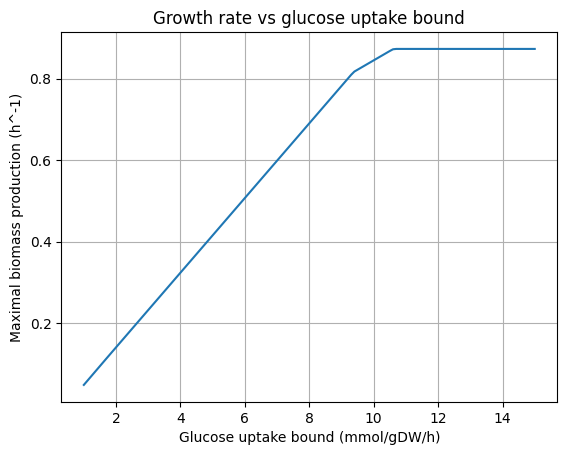

In [26]:
plt.plot(bounds, growth)
plt.xlabel("Glucose uptake bound (mmol/gDW/h)")
plt.ylabel("Maximal biomass production (h^-1)")
plt.title("Growth rate vs glucose uptake bound")
plt.grid()
plt.show()

### b) Does the growth rate keep increasing?

In [27]:
for b in [1.0, 5.0, 9.0, 10.0, 11.0, 15.0]:
    s = results[b]
    print("bound", b, "-> growth", round(s.objective_value, 4), "glucose flux", round(s.fluxes["EX_glc__D_e"], 3))

bound 1.0 -> growth 0.0484 glucose flux -1.0
bound 5.0 -> growth 0.4156 glucose flux -5.0
bound 9.0 -> growth 0.7823 glucose flux -9.0
bound 10.0 -> growth 0.8452 glucose flux -10.0
bound 11.0 -> growth 0.8733 glucose flux -10.62
bound 15.0 -> growth 0.8733 glucose flux -10.62


In [28]:
# check which constrained reactions are at their limit when glucose is not limiting
s = results[15.0]
for reaction in model.reactions:
    if reaction.id not in activity_data:
        continue
    flux = s.fluxes[reaction.id]
    if flux != 0 and (abs(flux - reaction.upper_bound) < 1e-6 or abs(flux - reaction.lower_bound) < 1e-6):
        print(reaction.id, "flux", round(flux, 3), "bounds", reaction.bounds)

ACKr flux -2.5 bounds (-2.5, 2.5)
CYTBD flux 41.1 bounds (0, 41.1)
GND flux 5.6 bounds (0, 5.6)


### c) The three segments

In [29]:
# exchange fluxes at one point in each segment
for b in [5.0, 10.0, 15.0]:
    print("bound", b)
    for reaction in model.reactions:
        if reaction.id.startswith("EX_") and abs(results[b].fluxes[reaction.id]) > 1e-6:
            print("  ", reaction.id, round(results[b].fluxes[reaction.id], 3))

bound 5.0
   EX_co2_e 12.314
   EX_glc__D_e -5.0
   EX_h_e 8.337
   EX_h2o_e 15.341
   EX_nh4_e -2.266
   EX_o2_e -11.834
   EX_pi_e -1.529
bound 10.0
   EX_ac_e 1.252
   EX_co2_e 21.527
   EX_glc__D_e -10.0
   EX_h_e 18.207
   EX_h2o_e 27.684
   EX_nh4_e -4.609
   EX_o2_e -20.55
   EX_pi_e -3.109
bound 15.0
   EX_ac_e 2.5
   EX_co2_e 21.56
   EX_glc__D_e -10.62
   EX_h_e 20.018
   EX_h2o_e 27.921
   EX_nh4_e -4.762
   EX_o2_e -20.55
   EX_pi_e -3.213


In [30]:
# exchange reactions that are zero in the first segment but not in the second
for reaction in model.reactions:
    if reaction.id.startswith("EX_"):
        before = results[5.0].fluxes[reaction.id]
        after = results[10.0].fluxes[reaction.id]
        if abs(before) < 1e-6 and abs(after) > 1e-6:
            print(reaction.id, reaction.name, round(after, 3))

EX_ac_e Acetate exchange 1.252


In [31]:
# put the glucose bounds back to the part 2 values
glucose.bounds = (-1000, 1000)